# PCA 主成分分析

**目标：** 用 PCA 对 Iris 数据集降维（4维 → 3维），并在 3D 散点图中可视化。


## 1. 导入库

加载需要的库：matplotlib（绘图）、sklearn PCA（降维）、load_iris（数据）

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA    # PCA 降维
from sklearn.datasets import load_iris   # Iris 数据集（4 维特征，3 类）
from mpl_toolkits.mplot3d import Axes3D  # 支持 3D 图

## 2. 加载 Iris 数据

- `data.data`：4 个特征（花萼长/宽、花瓣长/宽）
- `data.target`：3 个品种标签（0=setosa, 1=versicolor, 2=virginica）

In [8]:
# Iris: 150 样本，4 特征（花萼长/宽，花瓣长/宽），3 类各 50 个
data = load_iris()
y = data.target      # 标签 (150,)，值 0/1/2
X = data.data        # 特征 (150, 4)
print('特征形状:', X.shape)
print('标签:', y[:10])

特征形状: (150, 4)
标签: [0 0 0 0 0 0 0 0 0 0]


## 3. PCA 降维：4维 → 3维

`PCA(n_components=3)` 把 4 个特征降成 3 个主成分，保留最大方差方向。

`fit_transform` = 先拟合（找主成分方向）+ 再转换（把数据投影到新空间）。

In [9]:
# n_components=3：降到 3 维
# fit_transform 内部：① 算协方差矩阵 → 特征分解取前 3 个特征向量
#                    ② 数据 × 特征向量矩阵 → 降维
# explained_variance_ratio_：各主成分方差占比，加起来 ≈ 1
pca = PCA(n_components=3)
reduced_X = pca.fit_transform(X)  # (150, 3)
print('降维后形状:', reduced_X.shape)
print('各主成分方差占比:', pca.explained_variance_ratio_)

降维后形状: (150, 3)
各主成分方差占比: [0.92461872 0.05306648 0.01710261]


## 4. 按品种分类数据

把 150 条数据按标签（0/1/2）拆成 3 组，分别存到 3 个列表里，方便按不同颜色绘制。

In [10]:
# 按类别拆成三组，每组存 PC1/PC2/PC3 坐标列表
red_x, red_y, red_z = [], [], []        # Class 0 (setosa)
blue_x, blue_y, blue_z = [], [], []     # Class 1 (versicolor)
green_x, green_y, green_z = [], [], []  # Class 2 (virginica)

for i in range(len(reduced_X)): # 取第 0 维长度，即 150
    if y[i] == 0:       # 类别 0 → 红色组
        red_x.append(reduced_X[i][0])
        red_y.append(reduced_X[i][1])
        red_z.append(reduced_X[i][2])
    elif y[i] == 1:     # 类别 1 → 蓝色组
        blue_x.append(reduced_X[i][0])
        blue_y.append(reduced_X[i][1])
        blue_z.append(reduced_X[i][2])
    else:               # 类别 2 → 绿色组
        green_x.append(reduced_X[i][0])
        green_y.append(reduced_X[i][1])
        green_z.append(reduced_X[i][2])

## 5. 3D 散点图可视化

三个品种用不同颜色和标记显示。降维后前 3 个主成分如果能把三类分开，说明 PCA 保留了有效信息。

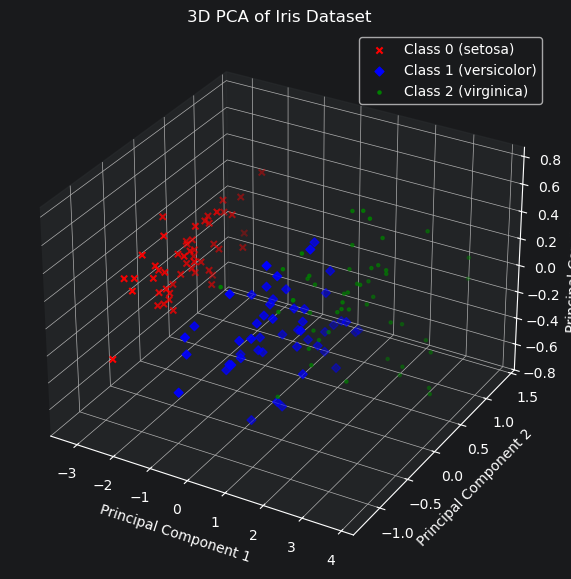

In [13]:
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection='3d')  # 三维坐标系

# 三种类别分别用红/蓝/绿 + 不同 marker 绘制
ax.scatter(red_x, red_y, red_z, c='r', marker='x', label='Class 0 (setosa)')
ax.scatter(blue_x, blue_y, blue_z, c='b', marker='D', label='Class 1 (versicolor)')
ax.scatter(green_x, green_y, green_z, c='g', marker='.', label='Class 2 (virginica)')

ax.legend()
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.title('3D PCA of Iris Dataset')
plt.show()

---
## 📐 PCA 原理速览

### 核心思想
把原始数据投影到**方差最大的方向**上，用少数几个新特征（主成分）近似原数据。

### 数学步骤（简述）

1. **数据中心化**：每个特征减去均值，使数据以原点为中心
   $$X_{\text{centered}} = X - \bar{X}$$

2. **计算协方差矩阵**：捕捉特征之间的协变关系
    
> **协方差 vs 皮尔逊相关系数：**
> 
> 协方差矩阵元素 $C_{ij} = \text{Cov}(X_i, X_j)$ 的值域为 $\mathbb{R}$，受变量尺度影响。
> 
> 衡量线性相关性强弱应使用**皮尔逊相关系数**，标准化到 $[-1, 1]$：
> 
> $$\rho_{ij} = \frac{\text{Cov}(X_i, X_j)}{\sigma_{X_i} \sigma_{X_j}} = \frac{C_{ij}}{\sqrt{C_{ii} \cdot C_{jj}}}$$

   $$C = \frac{1}{n-1} X_{\text{centered}}^T X_{\text{centered}}$$

3. **特征值分解**：对协方差矩阵求特征值和特征向量
   - 特征向量 → 主成分的方向
   - 特征值 → 该方向上的方差大小
   
> **为什么特征向量就是主方向、特征值就是方差？**
> 
> 在 $n$ 维特征空间中，每个坐标轴代表一个特征方向。协方差矩阵的元素 $C_{ij}$ 刻画的是特征 $i$ 和特征 $j$ 两个方向之间的「耦合」——它们同涨同跌的倾向。当 $C_{ij} \neq 0$ 时，两个特征方向不是独立波动的。
> 
> 把 $C$ 作用到任意方向 $\mathbf{w}$ 上，输出分量 $(C\mathbf{w})_i = \sum_j C_{ij} w_j$，本质是：所有特征方向通过它们和特征 $i$ 的耦合，共同对输出方向第 $i$ 分量产生「拖拽」。
> 
> 由此产生两种情况：
> - 若 $\mathbf{w}$ 不是特征向量：各方位的拖拽不均匀，输出方向被拽歪，和输入方向产生角度偏差。
> - 若 $\mathbf{w}$ 是特征向量：各方位的耦合恰好达成平衡，拖拽相互抵消，输出与输入完全同向（$C\mathbf{v} = \lambda\mathbf{v}$），偏差为零。
> 
> 因此，特征向量是在协方差变换下**不发生方向偏转**的轴——所有特征间耦合对它「拽不动」。沿着这个轴投影，数据方差达到极值。特征值 $\lambda$ 就是沿该轴的方差大小：$\lambda = \mathbf{v}^T C \mathbf{v}$。

4. **选前 k 个主成分**：按特征值从大到小排序，取前 k 个
   
> **为什么只取前 k 个，不取全部？**
> 
> 降维就发生在这一步。前两步（特征向量）完成了坐标系的**旋转**——找到偏差最小的新轴；这一步完成**丢弃**——把维度从 $n$ 削到 $k$。取全部 $n$ 个主成分等于只做了旋转，维度没减；而后面特征值小的主成分承载的方差几乎全是噪声，扔掉它用方差的微小代价换来维度的巨大压缩，实现降维。
> 
> **为什么按特征值大取小弃？方差小不是更精准吗？**
> 
> 这里要区分两个「偏差」：
> - 第 3 步的偏差：**方向偏转**——输出方向和输入方向是否一致。所有特征向量在这方面都是零偏转，和特征值大小无关。
> - 第 4 步的方差：**数据的散布**——数据沿这个轴散得有多开。
> 
> 特征值大 → 数据散得开 → 能区分不同样本 → 信息量大，保留。特征值小 → 数据挤成一团 → 所有样本看起来差不多 → 信息量小，丢弃。
> 
> PCA 取舍轴的标准是**信息量**，不是方向稳定性。扔小留大，本质是扔噪声留信号。

5. **投影**：原始数据 $\times$ 选出的特征向量矩阵 $\to$ 降维后的数据
   
> **矩阵维度变化：**
> 
> - 原数据 $X$：$n \times d$（$n$ 个样本，$d$ 个特征）
> - 完整特征向量矩阵 $V$：$d \times d$（每列一个特征向量，按特征值降序排列）
> - 取前 $k$ 个主成分时，切掉后 $d-k$ 列，得到 $V_k$：$d \times k$
> - 投影：$X_{\text{centered}} \cdot V_k$ $\to$ $n \times k$
> 
> 维度从 $d$ 降到 $k$，靠的是**直接抛弃那些轴**，而不是把后几列填零。

### 如何选 k（降维到几维？）

```python
pca = PCA(n_components=0.95)  # 保留 95% 的方差
# 或者手动设固定维度
pca = PCA(n_components=3)      # 降到 3 维
```

用 `explained_variance_ratio_` 看累积方差占比：

```python
print(pca.explained_variance_ratio_)
# [0.9246, 0.0530, 0.0171]  ← 前 3 个主成分保留了 99.5%
print(pca.explained_variance_ratio_.cumsum())
# [0.9246, 0.9776, 0.9947]
```

### 一句话总结
PCA 找数据方差最大的方向 → 扔掉方差小的方向 → 用更少的维度表示数据。
